C:\Users\Hp\AppData\Local\Temp\ipykernel_1504\678302846.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='PD', data=rating_df, palette='RdYlGn_r')


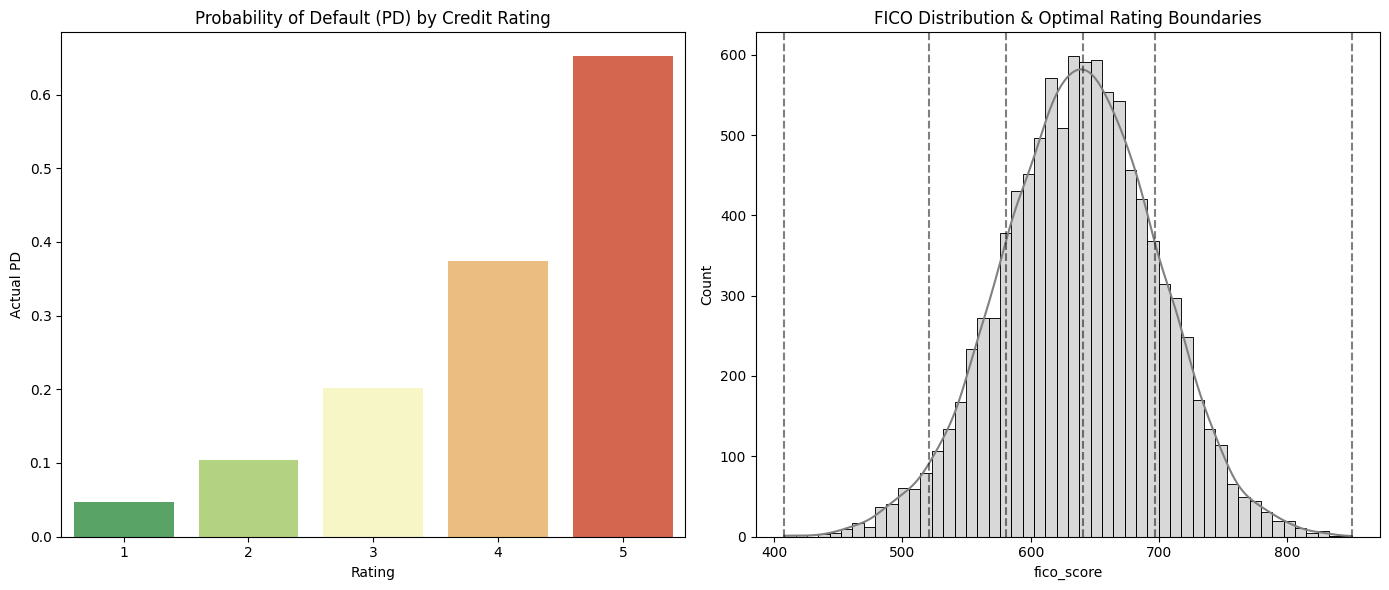

   Rating FICO_Range        PD
0       1    697-850  0.046470
1       2    641-697  0.103629
2       3    581-641  0.201937
3       4    521-581  0.373973
4       5    408-521  0.651899


<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

# 2. QUANTIZATION LOGIC (Dynamic Programming for Max Likelihood)
def log_likelihood(k, n):
    if n == 0: return 0
    p = k / n
    if p <= 0 or p >= 1: return 0
    return k * np.log(p) + (n - k) * np.log(1 - p)

# Aggregate data by FICO score
stats = df.groupby('fico_score')['default'].agg(['count', 'sum']).reset_index()
ficos, n_vals, k_vals = stats['fico_score'].values, stats['count'].values, stats['sum'].values
N, num_buckets = len(ficos), 5

# Precompute log-likelihood matrix
ll_matrix = np.zeros((N, N))
for i in range(N):
    n_sum, k_sum = 0, 0
    for j in range(i, N):
        n_sum += n_vals[j]
        k_sum += k_vals[j]
        ll_matrix[i, j] = log_likelihood(k_sum, n_sum)

# DP for optimal bucket boundaries
dp = np.full((num_buckets + 1, N + 1), -np.inf)
parent = np.zeros((num_buckets + 1, N + 1), dtype=int)
dp[1, 1:] = [ll_matrix[0, i-1] for i in range(1, N + 1)]

for b in range(2, num_buckets + 1):
    for i in range(b, N + 1):
        for j in range(b-1, i):
            val = dp[b-1, j] + ll_matrix[j, i-1]
            if val > dp[b, i]:
                dp[b, i], parent[b, i] = val, j

# Extract FICO boundaries
curr, boundary_indices = N, []
for b in range(num_buckets, 1, -1):
    curr = parent[b, curr]
    boundary_indices.append(curr)
bounds = [ficos[0]] + sorted([ficos[i] for i in boundary_indices]) + [ficos[-1]]

# 3. CREATE RATING DATAFRAME (rating_df)
rating_list = []
for i in range(num_buckets):
    low, high = bounds[i], bounds[i+1]
    bucket_data = df[(df['fico_score'] >= low) & (df['fico_score'] <= high)]
    rating_list.append({'FICO_Range': f"{low}-{high}", 'PD': bucket_data['default'].mean()})

rating_df = pd.DataFrame(rating_list).sort_values('PD').reset_index(drop=True)
rating_df['Rating'] = range(1, num_buckets + 1)

# 4. VISUALIZATION
plt.figure(figsize=(14, 6))

# Plot A: PD per Rating
plt.subplot(1, 2, 1)
sns.barplot(x='Rating', y='PD', data=rating_df, palette='RdYlGn_r')
plt.title('Probability of Default (PD) by Credit Rating')
plt.ylabel('Actual PD')

# Plot B: FICO Distribution with Boundaries
plt.subplot(1, 2, 2)
sns.histplot(df['fico_score'], bins=50, kde=True, color='gray', alpha=0.3)
for b in bounds:
    plt.axvline(b, color='black', linestyle='--', alpha=0.5)
plt.title('FICO Distribution & Optimal Rating Boundaries')

plt.tight_layout()
plt.show()
plt.savefig('FICO scores')

print(rating_df[['Rating', 'FICO_Range', 'PD']])